# TP3 - Attribution Multicanal Lumina & Co

#### Contexte

Le dataset `touchpoints.csv` contient l'historique de tous les points de contact entre Lumina & Co et ses clients, sur les 6 campagnes menées entre l'été 2025 et l'été 2026. `campaigns.csv` contient les métriques agrégées par campagne.

Le CMO reçoit chaque semaine des rapports contradictoires de ses différents canaux. Votre mission : lui donner des chiffres clairs et une première lecture critique de ce qu'ils veulent vraiment dire.


#### Chargement


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("Lumina & Co - CRM")

campaigns_df = pd.read_csv(DATA_DIR / "campaigns.csv")
campaigns_df.columns = campaigns_df.columns.str.strip()
campaigns_df["campaign_name"] = campaigns_df["campaign_name"].str.strip()
campaigns_df["primary_channel"] = campaigns_df["primary_channel"].str.strip()

touchpoints_df = pd.read_csv(DATA_DIR / "touchpoints.csv")
customers_df = pd.read_csv(DATA_DIR / "customers.csv")
transactions_df = pd.read_csv(DATA_DIR / "transactions.csv")

customers_df["first_purchase"] = pd.to_datetime(customers_df["first_purchase"], errors="coerce")
transactions_df["invoice_date"] = pd.to_datetime(transactions_df["invoice_date"], errors="coerce")
transactions_df["invoice_id"] = pd.to_numeric(transactions_df["invoice_id"], errors="coerce")
touchpoints_df["invoice_id"] = pd.to_numeric(touchpoints_df["invoice_id"], errors="coerce")

print("Campagnes :", len(campaigns_df), "| Touchpoints :", f"{len(touchpoints_df):,}")
print("Clients :", f"{len(customers_df):,}", "| Transactions :", f"{len(transactions_df):,}")
print("Canaux :", sorted(touchpoints_df["channel"].unique()))
display(campaigns_df[[
    "campaign_name", "n_clients", "n_clicks", "n_conversions",
    "total_cost", "revenue", "conversion_rate", "cpa", "roas", "primary_channel",
]].round(2))


Campagnes : 6 | Touchpoints : 1,080,897
Clients : 50,295 | Transactions : 1,613,433
Canaux : ['affiliate', 'direct', 'display', 'email', 'retargeting', 'search_paid', 'social']


,campaign_name,n_clients,n_clicks,n_conversions,total_cost,revenue,conversion_rate,cpa,roas,primary_channel
0,Back_to_School,25527,85710,13192,159256.41,725541.50,0.52,12.07,4.56,social
1,Black_Friday,26937,101841,18777,205749.41,957170.87,0.70,10.96,4.65,display
2,Spring_Launch,26612,103868,20372,374813.33,1686555.27,0.77,18.40,4.50,display
3,Summer_Sale,25378,84734,12714,226774.16,621009.60,0.50,17.84,2.74,display
4,Valentine,25850,90122,15141,247465.96,853184.79,0.59,16.34,3.45,display
5,Winter_Promo,25638,88093,14170,133949.00,716632.64,0.55,9.45,5.35,display


#### Étape 1 : KPIs par canal et par campagne

À partir de `campaigns.csv` et `touchpoints.csv`, calculez pour chaque canal : le CAC, le CPA, le ROAS, le taux de conversion.

**Définitions utilisées :**
- **CPA** = coût total du canal / nombre de conversions last-touch
- **CAC** = coût total du canal / nombre de *primo-achats* last-touch (même coût, moins de conversions)
- **ROAS** = CA attribué last-touch / coût total du canal
- **Taux de conversion** = conversions last-touch / clics
- Un **primo-achat** : date de la facture convertie (`transactions.csv`) = `first_purchase` (`customers.csv`)


In [11]:
# CA campagne réparti à parts égales entre conversions last-touch
rev_par_conv = (
    campaigns_df.set_index("campaign_name")["revenue"]
    / campaigns_df.set_index("campaign_name")["n_conversions"]
)

invoices = (
    transactions_df.assign(line_total=lambda d: d["quantity"] * d["unit_price"].clip(lower=0))
    .groupby("invoice_id", as_index=False)
    .agg(invoice_date=("invoice_date", "min"), invoice_ca=("line_total", "sum"))
)

conv_df = touchpoints_df.loc[touchpoints_df["converted"] == 1].copy()
conv_df["revenue_attrib"] = conv_df["campaign_name"].map(rev_par_conv)
conv_df = conv_df.merge(invoices, on="invoice_id", how="left")
conv_df = conv_df.merge(
    customers_df[["customer_id", "first_purchase", "total_spent", "n_orders", "tenure_days", "avg_basket"]],
    on="customer_id",
    how="left",
)
conv_df["primo_achat"] = (
    conv_df["invoice_date"].dt.normalize() == conv_df["first_purchase"].dt.normalize()
)

print(
    f"Conversions last-touch : {len(conv_df):,} | "
    f"Primo-achats : {conv_df['primo_achat'].sum():,} "
    f"({conv_df['primo_achat'].mean() * 100:.1f}%)"
)

cost_ch = touchpoints_df.groupby("channel", as_index=False).agg(
    cost=("cost", "sum"),
    n_touchpoints=("touchpoint_id", "count"),
    n_clients=("customer_id", "nunique"),
    n_clicks=("click", "sum"),
)
last_ch = conv_df.groupby("channel", as_index=False).agg(
    n_conversions=("touchpoint_id", "count"),
    n_primo=("primo_achat", "sum"),
    revenue=("revenue_attrib", "sum"),
)

kpis_canal = cost_ch.merge(last_ch, on="channel", how="left").fillna(0)
kpis_canal["CPA"] = np.where(kpis_canal["n_conversions"] > 0, kpis_canal["cost"] / kpis_canal["n_conversions"], np.nan)
kpis_canal["CAC"] = np.where(kpis_canal["n_primo"] > 0, kpis_canal["cost"] / kpis_canal["n_primo"], np.nan)
kpis_canal["ROAS"] = np.where(kpis_canal["cost"] > 0, kpis_canal["revenue"] / kpis_canal["cost"], np.nan)
kpis_canal["taux_conversion"] = np.where(kpis_canal["n_clicks"] > 0, kpis_canal["n_conversions"] / kpis_canal["n_clicks"], 0)

print("\nKPIs par canal (coût = toutes les impressions du canal ; conversions = last-touch) :")
display(kpis_canal.round(2))

print("\nKPIs par campagne (fichier agrégé) :")
display(
    campaigns_df[[
        "campaign_name", "primary_channel", "total_cost", "revenue",
        "cpa", "roas", "conversion_rate",
    ]].sort_values("roas", ascending=False).round(2)
)


Conversions last-touch : 94,366 | Primo-achats : 1,749 (1.9%)

KPIs par canal (coût = toutes les impressions du canal ; conversions = last-touch) :


,channel,cost,n_touchpoints,n_clients,n_clicks,n_conversions,n_primo,revenue,CPA,CAC,ROAS,taux_conversion
0,affiliate,1128776.74,54516,20800,44884,26979.0,507.0,1580032.58,41.84,2226.38,1.40,0.60
1,direct,0.00,43919,18232,34441,16803.0,277.0,958752.74,0.00,0.00,NaN,0.49
2,display,1482.10,316530,47555,142192,0.0,0.0,0.00,NaN,NaN,0.00,0.00
3,email,2263.28,150733,43141,75666,14355.0,258.0,772153.45,0.16,8.77,341.17,0.19
4,retargeting,1897.65,158102,43482,83548,22563.0,441.0,1414046.05,0.08,4.30,745.16,0.27
5,search_paid,47264.48,41334,17513,31548,13666.0,266.0,835109.85,3.46,177.69,17.67,0.43
6,social,166324.04,315763,47500,142089,0.0,0.0,0.00,NaN,NaN,0.00,0.00



KPIs par campagne (fichier agrégé) :


,campaign_name,primary_channel,total_cost,revenue,cpa,roas,conversion_rate
5,Winter_Promo,display,133949.00,716632.64,9.45,5.35,0.55
1,Black_Friday,display,205749.41,957170.87,10.96,4.65,0.70
0,Back_to_School,social,159256.41,725541.50,12.07,4.56,0.52
2,Spring_Launch,display,374813.33,1686555.27,18.40,4.50,0.77
4,Valentine,display,247465.96,853184.79,16.34,3.45,0.59
3,Summer_Sale,display,226774.16,621009.60,17.84,2.74,0.50


Classements (1 = meilleur). Display/social : pas de conversion last-touch → CPA/CAC non définis.


,rang_CPA,rang_CAC,rang_ROAS,rang_conv
channel,,,,
retargeting,2.0,2.0,1.0,4.0
email,3.0,3.0,2.0,5.0
search_paid,4.0,4.0,3.0,3.0
affiliate,5.0,5.0,4.0,1.0
display,NaN,NaN,5.0,6.0
social,NaN,NaN,5.0,6.0
direct,1.0,1.0,NaN,2.0



Ordre ROAS : ['retargeting', 'email', 'search_paid', 'affiliate', 'display', 'social', 'direct']
Ordre CPA  : ['direct', 'retargeting', 'email', 'search_paid', 'affiliate', 'display', 'social']
Ordre CAC  : ['direct', 'retargeting', 'email', 'search_paid', 'affiliate', 'display', 'social']
Ordre conv : ['affiliate', 'direct', 'search_paid', 'retargeting', 'email', 'display', 'social']


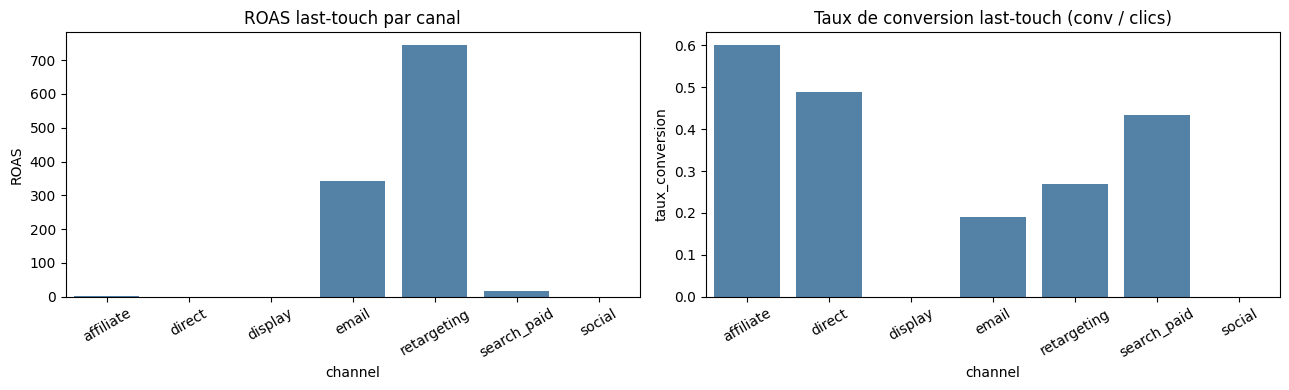

In [12]:
def classement(serie, plus_petit_mieux=False):
    s = serie.replace([np.inf, -np.inf], np.nan)
    return s.rank(ascending=plus_petit_mieux, method="min")

rank = kpis_canal.set_index("channel")[["CPA", "CAC", "ROAS", "taux_conversion"]].copy()
rank["rang_CPA"] = classement(rank["CPA"], plus_petit_mieux=True)
rank["rang_CAC"] = classement(rank["CAC"], plus_petit_mieux=True)
rank["rang_ROAS"] = classement(rank["ROAS"], plus_petit_mieux=False)
rank["rang_conv"] = classement(rank["taux_conversion"], plus_petit_mieux=False)

print("Classements (1 = meilleur). Display/social : pas de conversion last-touch → CPA/CAC non définis.")
display(rank[["rang_CPA", "rang_CAC", "rang_ROAS", "rang_conv"]].sort_values("rang_ROAS"))

print("\nOrdre ROAS :", list(kpis_canal.sort_values("ROAS", ascending=False)["channel"]))
print("Ordre CPA  :", list(kpis_canal.sort_values("CPA", ascending=True)["channel"]))
print("Ordre CAC  :", list(kpis_canal.sort_values("CAC", ascending=True)["channel"]))
print("Ordre conv :", list(kpis_canal.sort_values("taux_conversion", ascending=False)["channel"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_df = kpis_canal.copy()
sns.barplot(data=plot_df, x="channel", y="ROAS", color="steelblue", ax=axes[0])
axes[0].set_title("ROAS last-touch par canal")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(data=plot_df, x="channel", y="taux_conversion", color="steelblue", ax=axes[1])
axes[1].set_title("Taux de conversion last-touch (conv / clics)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


#### Lecture — classements et display

**Le classement n'est pas le même selon la métrique.** Affiliate gagne en taux de conversion last-touch (il « ferme » la vente, souvent au % de commission — d'où un coût énorme ~84 % du budget). Retargeting et e-mail ont un CPA/CAC minuscule et un ROAS astronomique, parce que leur *coût média enregistré* est quasi nul alors qu'ils récupèrent beaucoup de last-touch. Direct n'a **aucun coût** : le CPA/CAC tombent à 0, le ROAS n'est pas interprétable.

**Display ne doit pas être jugé sur sa conversion directe.** Ici display (et social) : **0 conversion last-touch**, ROAS 0, CPA indéfini. En first-touch des parcours convertis, ils pèsent ~41 % chacun. Les juger au last-click conclurait à « couper le display » — alors qu'il allume le parcours. Le classement last-touch **sous-estime structurellement** display/social (découverte) et **surestime** affiliate / retargeting / direct (closing).


In [13]:
# primary_channel vs volume, dépense, et nos classements
vol = (
    touchpoints_df.groupby(["campaign_name", "channel"]).size()
    .unstack(fill_value=0)
)
spend = (
    touchpoints_df.groupby(["campaign_name", "channel"])["cost"].sum()
    .unstack(fill_value=0)
)

cmp_primary = campaigns_df[["campaign_name", "primary_channel"]].copy()
cmp_primary["canal_le_plus_de_touchpoints"] = vol.idxmax(axis=1).reindex(cmp_primary["campaign_name"]).values
cmp_primary["canal_le_plus_de_depense"] = spend.idxmax(axis=1).reindex(cmp_primary["campaign_name"]).values
print("primary_channel vs volume de touchpoints vs dépense :")
display(cmp_primary)

print("\nprimary_channel n'est le n°1 d'aucun classement last-touch (CPA / CAC / ROAS / conv),")
print("sauf Back_to_School dont le primary est social — canal sans conversion last-touch.")
print("C'est le canal *principal en volume d'impressions*, pas le plus performant en ROI.")


primary_channel vs volume de touchpoints vs dépense :


,campaign_name,primary_channel,canal_le_plus_de_touchpoints,canal_le_plus_de_depense
0,Back_to_School,social,social,affiliate
1,Black_Friday,display,display,affiliate
2,Spring_Launch,display,display,affiliate
3,Summer_Sale,display,display,affiliate
4,Valentine,display,display,affiliate
5,Winter_Promo,display,display,affiliate



primary_channel n'est le n°1 d'aucun classement last-touch (CPA / CAC / ROAS / conv),
sauf Back_to_School dont le primary est social — canal sans conversion last-touch.
C'est le canal *principal en volume d'impressions*, pas le plus performant en ROI.


#### Lecture — `primary_channel`

`primary_channel` **n'est pas** le canal le plus performant (ni en CPA, ni en ROAS). Il **coïncide avec le canal qui a le plus de touchpoints** (display sur 5 campagnes, social sur Back_to_School). Le canal le plus *dépensier* est partout **affiliate** (commissions).

Le champ désigne donc le **canal porteur / de diffusion**, pas le gagnant du ranking. Un CMO qui lirait `primary_channel` comme « le meilleur canal » se tromperait de levier budgétaire.


In [14]:
print("CAC vs CPA (même coût canal, dénominateur différent) :")
cac_cpa = kpis_canal[["channel", "cost", "n_conversions", "n_primo", "CPA", "CAC"]].copy()
cac_cpa["ratio_CAC_sur_CPA"] = cac_cpa["CAC"] / cac_cpa["CPA"]
display(cac_cpa.round(2))

print(
    "\nPrimo-achats = conversions dont invoice_date (jour) = first_purchase."
)
print("Si CAC ≈ CPA, le filtre primo est trop large (on compterait les réachats comme de l'acquisition).")
print("Ici les primo-achats sont une petite fraction des conversions → CAC >> CPA : le filtre est cohérent.")


CAC vs CPA (même coût canal, dénominateur différent) :


,channel,cost,n_conversions,n_primo,CPA,CAC,ratio_CAC_sur_CPA
0,affiliate,1128776.74,26979.0,507.0,41.84,2226.38,53.21
1,direct,0.00,16803.0,277.0,0.00,0.00,NaN
2,display,1482.10,0.0,0.0,NaN,NaN,NaN
3,email,2263.28,14355.0,258.0,0.16,8.77,55.64
4,retargeting,1897.65,22563.0,441.0,0.08,4.30,51.16
5,search_paid,47264.48,13666.0,266.0,3.46,177.69,51.38
6,social,166324.04,0.0,0.0,NaN,NaN,NaN



Primo-achats = conversions dont invoice_date (jour) = first_purchase.
Si CAC ≈ CPA, le filtre primo est trop large (on compterait les réachats comme de l'acquisition).
Ici les primo-achats sont une petite fraction des conversions → CAC >> CPA : le filtre est cohérent.


#### Lecture — CAC ≠ CPA et vanity metrics

Le **CPA** divise le coût par *toutes* les conversions (y compris le réachat d'un client déjà en base). Le **CAC** ne garde que les **primo-achats**. Même numérateur, plus petit dénominateur → CAC systématiquement plus élevé. Des chiffres proches signifieraient un filtre primo cassé.

**Vanity metrics** si on les regarde isolément dans `touchpoints.csv` :
- **nombre de touchpoints** : le display « gagne » sans rien clôturer ;
- **nombre de clics** : volume, pas de valeur ;
- **coût** : dépenser n'est pas performer ;
- **conversions** brutes : sans coût ni primo, on mélange acquisition et réachat, et on attribue tout au last-click.

Elles deviennent des **KPI** une fois **combinées** : coût / conversions = CPA, coût / primo = CAC, CA / coût = ROAS, conversions / clics = taux. Le KPI, c'est le *ratio* et le *dénominateur choisi*, pas le compteur.


In [15]:
# Optionnel : CLTV simplifiée des clients acquis (primo last-touch) puis LTV:CAC
MARGIN = 0.40
LIFETIME_YEARS = 3.0

primo = conv_df.loc[conv_df["primo_achat"]].copy()
primo["years"] = np.maximum(primo["tenure_days"] / 365.0, 1 / 12)
primo["annualized"] = primo["total_spent"] / primo["years"]
primo["CLTV"] = primo["annualized"] * LIFETIME_YEARS * MARGIN

cltv = (
    primo.groupby("channel", as_index=False)
    .agg(n_acquis=("customer_id", "nunique"), CLTV_moy=("CLTV", "mean"))
)
cltv = cltv.merge(kpis_canal[["channel", "CAC"]], on="channel", how="left")
cltv["LTV_CAC"] = cltv["CLTV_moy"] / cltv["CAC"].replace(0, np.nan)
cltv = cltv.sort_values("LTV_CAC", ascending=False)

print(f"Hypothèses : durée de vie {LIFETIME_YEARS:.0f} ans, marge {MARGIN:.0%}, rythme = total_spent / max(tenure, 1 mois).")
print("Un canal 'bon CAC' n'est pas forcément le meilleur une fois la CLTV vue (qualité des acquis).")
display(cltv.round(2))


Hypothèses : durée de vie 3 ans, marge 40%, rythme = total_spent / max(tenure, 1 mois).
Un canal 'bon CAC' n'est pas forcément le meilleur une fois la CLTV vue (qualité des acquis).


,channel,n_acquis,CLTV_moy,CAC,LTV_CAC
3,retargeting,435,10518.71,4.30,2444.48
2,email,257,6179.07,8.77,704.38
4,search_paid,266,10599.47,177.69,59.65
0,affiliate,501,12478.33,2226.38,5.60
1,direct,274,7607.52,0.00,NaN


#### Lecture — LTV:CAC (optionnel)

Hypothèses explicites (à dire en présentation) : marge 40 %, durée de vie 3 ans.

Le classement **change** par rapport au seul CAC : un CAC très bas (e-mail, retargeting) donne un LTV:CAC énorme, mais ces canaux « acquièrent » surtout des gens déjà réchauffés par display/social. Affiliate a un CAC élevé (~2 200 €) : une partie de la commission, pas un média d'acquisition pur. Direct : CAC 0, ratio non comparable.

**Un bon CAC n'est pas toujours un bon canal** si les clients acquis dépensent peu, ou si le canal ne fait que réclamer le last-click. LTV:CAC évite de couper un canal cher qui ramène des gros comptes — et d'aduler un canal « gratuit » qui ne crée pas la demande.


#### Étape 2 : Comparaison first touch vs last touch


Touchpoints par parcours (journey_id) :


,n_touchpoints
count,214897.00
mean,5.03
std,2.05
min,1.00
25%,3.00
50%,5.00
75%,7.00
max,9.00



Canaux en 1re position (tous parcours) vs last-touch des conversions :


,% première position,% dernière avant conversion
channel,,
social,37.6,0.0
display,37.5,0.0
retargeting,10.1,23.9
email,10.0,15.2
affiliate,1.7,28.6
search_paid,1.6,14.5
direct,1.5,17.8


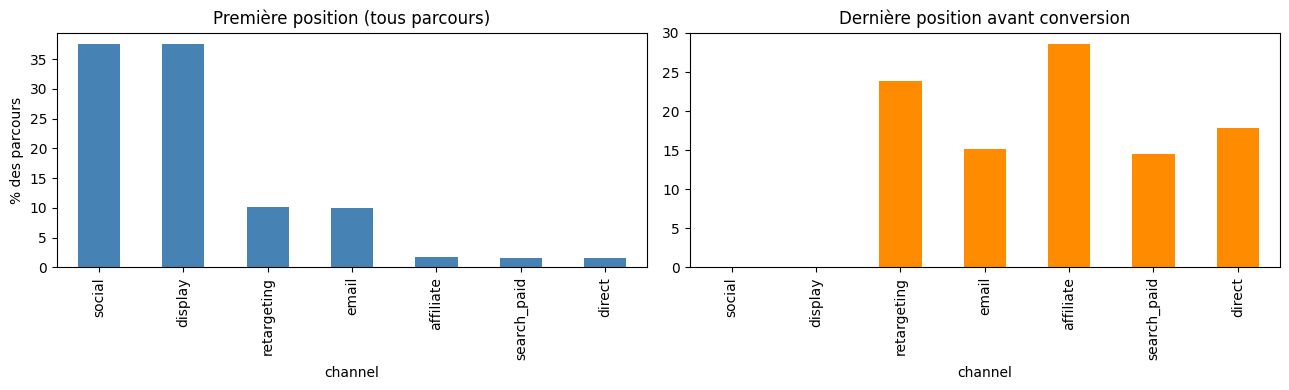

In [16]:
print("Touchpoints par parcours (journey_id) :")
display(touchpoints_df.groupby("journey_id").size().describe().to_frame("n_touchpoints").round(2))

idx_first = touchpoints_df.groupby("journey_id")["position"].idxmin()
first_all = touchpoints_df.loc[idx_first, "channel"].value_counts(normalize=True).mul(100).rename("% première position")
last_all = (
    touchpoints_df.loc[touchpoints_df["is_last_before_conversion"] == 1, "channel"]
    .value_counts(normalize=True).mul(100).rename("% dernière avant conversion")
)
orient = pd.concat([first_all, last_all], axis=1).fillna(0)
print("\nCanaux en 1re position (tous parcours) vs last-touch des conversions :")
display(orient.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
orient["% première position"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Première position (tous parcours)")
axes[0].set_ylabel("% des parcours")
orient["% dernière avant conversion"].plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Dernière position avant conversion")
plt.tight_layout()
plt.show()


First touch — 100 % du crédit au premier contact du parcours :


,channel,n_conversions,valeur,pct_conversions,pct_valeur
2,display,38733,2278406.7,41.0,41.0
6,social,38373,2264619.5,40.7,40.7
0,affiliate,3665,216139.9,3.9,3.9
4,retargeting,3558,211893.1,3.8,3.8
5,search_paid,3408,201432.5,3.6,3.6
3,email,3358,195300.9,3.6,3.5
1,direct,3271,192302.1,3.5,3.5


Last touch — 100 % du crédit au dernier contact avant l'achat :


,channel,n_conversions,valeur,pct_conversions,pct_valeur
0,affiliate,26979,1580032.6,28.6,28.4
3,retargeting,22563,1414046.1,23.9,25.4
1,direct,16803,958752.7,17.8,17.2
4,search_paid,13666,835109.8,14.5,15.0
2,email,14355,772153.4,15.2,13.9


Écart first − last (points de % de CA attribué) :


,channel,pct_valeur_first,pct_valeur_last,ecart_pp_valeur
0,affiliate,3.9,28.4,-24.5
1,direct,3.5,17.2,-13.8
2,display,41.0,0.0,41.0
3,email,3.5,13.9,-10.4
4,retargeting,3.8,25.4,-21.6
5,search_paid,3.6,15.0,-11.4
6,social,40.7,0.0,40.7


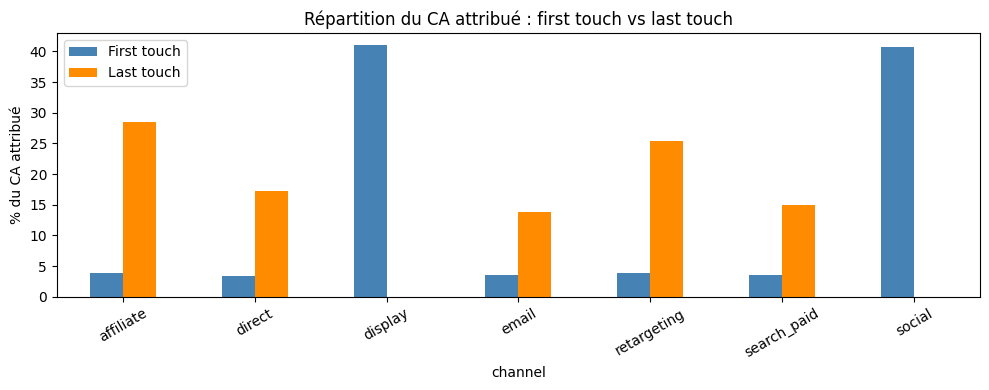

In [17]:
# Crédit 100 % first vs 100 % last sur les parcours CONVERTIS (valeur = CA campagne attribué)
idx_first_all = touchpoints_df.groupby("journey_id")["position"].idxmin()
first_map = touchpoints_df.loc[idx_first_all, ["journey_id", "channel"]].rename(columns={"channel": "first_channel"})

journeys = conv_df[["journey_id", "channel", "revenue_attrib"]].rename(columns={"channel": "last_channel"})
journeys = journeys.merge(first_map, on="journey_id", how="left")

def attribuer(col):
    g = journeys.groupby(col, as_index=False).agg(
        n_conversions=("journey_id", "count"),
        valeur=("revenue_attrib", "sum"),
    )
    g["pct_conversions"] = g["n_conversions"] / g["n_conversions"].sum() * 100
    g["pct_valeur"] = g["valeur"] / g["valeur"].sum() * 100
    return g.sort_values("valeur", ascending=False)

ft = attribuer("first_channel").rename(columns={"first_channel": "channel"})
lt = attribuer("last_channel").rename(columns={"last_channel": "channel"})

cmp = ft.merge(lt, on="channel", how="outer", suffixes=("_first", "_last")).fillna(0)
cmp["ecart_pp_valeur"] = cmp["pct_valeur_first"] - cmp["pct_valeur_last"]

print("First touch — 100 % du crédit au premier contact du parcours :")
display(ft.round(1))
print("Last touch — 100 % du crédit au dernier contact avant l'achat :")
display(lt.round(1))
print("Écart first − last (points de % de CA attribué) :")
display(cmp[["channel", "pct_valeur_first", "pct_valeur_last", "ecart_pp_valeur"]].round(1))

fig, ax = plt.subplots(figsize=(10, 4))
cmp_plot = cmp.set_index("channel")[["pct_valeur_first", "pct_valeur_last"]]
cmp_plot.plot(kind="bar", ax=ax, color=["steelblue", "darkorange"])
ax.set_ylabel("% du CA attribué")
ax.set_title("Répartition du CA attribué : first touch vs last touch")
ax.legend(["First touch", "Last touch"])
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


#### Analyse first touch vs last touch

- **First touch** favorise **display** et **social** (~41 % et ~41 % du CA attribué). Ce sont les portes d'entrée.
- **Last touch** favorise **affiliate** (~29 %), **retargeting** (~24 %), puis direct / e-mail / search_paid. Display et social tombent à **0 %**.
- Si le CMO ne regardait que le last touch, **display et social seraient sous-investis** (crédit nul) et l'affiliate / le retargeting **sur-crédités**. C'est cohérent avec les rôles : display/social = **découverte**, affiliate/retargeting/search = **closing**. Direct est le closing « gratuit » (saisie d'URL / marque).

#### Refléxion personnelle (vision silotée)

Sans comparaison croisée, chaque outil raconte sa victoire : Meta last-click, Google last-click, l'affiliation ses commissions. Un auto-entrepreneur qui ne voit que Meta Business Suite et GA **ne peut pas** conclure qu'un canal « performe » : il voit un compteur local, souvent une vanity metric ou un last-click. Le minimum raisonnable est de **tenir first et last en parallèle** (et un coût/CPA), pas un seul dashboard.

#### Recommandation

Sur ces données, **pas un modèle unique**. Un **multi-touch simple** (ou au moins le couple first + last) : le last-touch pour le budget *closing* (affiliate, search, retargeting), le first-touch pour ne pas tuer la *découverte* (display, social). Un last-touch seul reproduirait le biais du CMO « rapports contradictoires ». Un first-touch seul sous-investirait le closing payant.


#### Transactions, panier moyen et coût pub par mois

Une facture (`invoice_id`) = une transaction. Le **panier moyen** = CA du mois / nombre de factures. Le coût pub est la somme des `cost` de `touchpoints.csv`. Les campagnes ne commencent qu'en juin 2025 : avant, le coût est à 0.


Transactions vs coût pub par mois :


,mois,n_transactions,cout_pub,cout_par_transaction
0,2022-01,1,0.00,0.00
1,2022-02,1,0.00,0.00
2,2022-03,4,0.00,0.00
3,2022-04,7,0.00,0.00
4,2022-05,14,0.00,0.00
5,2022-06,23,0.00,0.00
6,2022-07,23,0.00,0.00
7,2022-08,34,0.00,0.00
8,2022-09,61,0.00,0.00
9,2022-10,82,0.00,0.00


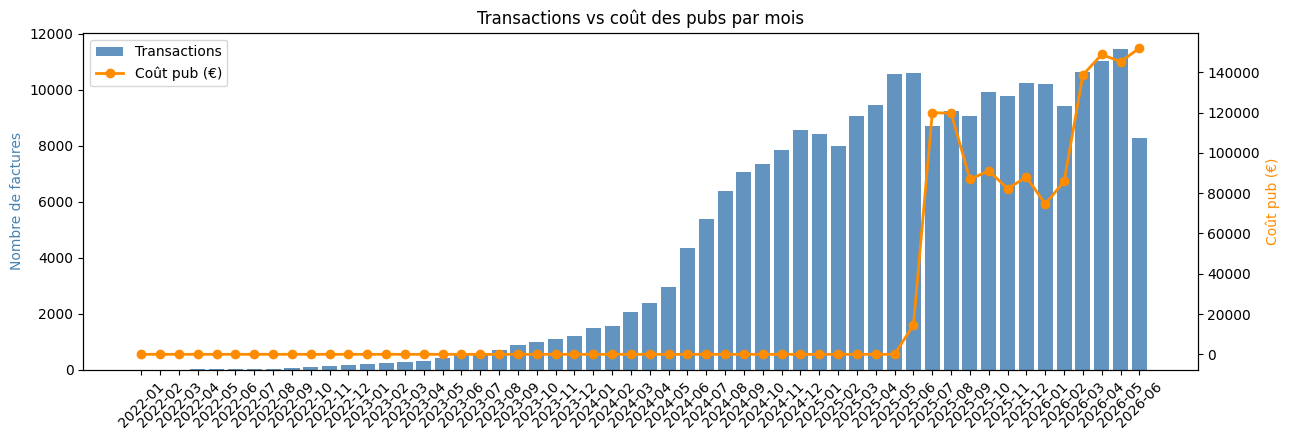

In [18]:
factures = (
    transactions_df.dropna(subset=["invoice_date"])
    .assign(
        line_total=lambda d: d["quantity"] * d["unit_price"].clip(lower=0),
        mois=lambda d: d["invoice_date"].dt.to_period("M").astype(str),
    )
    .groupby(["mois", "invoice_id"], as_index=False)
    .agg(ca=("line_total", "sum"))
)

tx_mois = factures.groupby("mois", as_index=False).agg(
    n_transactions=("invoice_id", "nunique"),
    panier_moyen=("ca", "mean"),
)

pub_mois = (
    touchpoints_df.assign(mois=lambda d: pd.to_datetime(d["timestamp"]).dt.to_period("M").astype(str))
    .groupby("mois", as_index=False)
    .agg(cout_pub=("cost", "sum"))
)

cmp_mois = tx_mois.merge(pub_mois, on="mois", how="outer").fillna(0).sort_values("mois")
cmp_mois["cout_par_transaction"] = np.where(
    cmp_mois["n_transactions"] > 0,
    cmp_mois["cout_pub"] / cmp_mois["n_transactions"],
    np.nan,
)

print("Transactions, panier moyen et coût pub par mois :")
display(cmp_mois.round(2))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1, ax1b = axes[0], axes[0].twinx()
ax1.bar(cmp_mois["mois"], cmp_mois["n_transactions"], color="steelblue", alpha=0.85, label="Transactions")
ax1b.plot(cmp_mois["mois"], cmp_mois["cout_pub"], color="darkorange", marker="o", linewidth=2, label="Coût pub (€)")
ax1.set_ylabel("Nombre de factures", color="steelblue")
ax1b.set_ylabel("Coût pub (€)", color="darkorange")
ax1.set_title("Transactions vs coût des pubs")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1b.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

ax2, ax2b = axes[1], axes[1].twinx()
ax2.bar(cmp_mois["mois"], cmp_mois["panier_moyen"], color="seagreen", alpha=0.85, label="Panier moyen")
ax2b.plot(cmp_mois["mois"], cmp_mois["cout_pub"], color="darkorange", marker="o", linewidth=2, label="Coût pub (€)")
ax2.set_ylabel("Panier moyen (€)", color="seagreen")
ax2b.set_ylabel("Coût pub (€)", color="darkorange")
ax2.set_title("Panier moyen vs coût des pubs")
ax2.tick_params(axis="x", rotation=45)
h3, l3 = ax2.get_legend_handles_labels()
h4, l4 = ax2b.get_legend_handles_labels()
ax2.legend(h3 + h4, l3 + l4, loc="upper left")

plt.tight_layout()
plt.show()


---

## Livrables

1. **KPIs** : tableau comparatif des canaux, classements CPA / CAC / ROAS / conversion (cellules étape 1)
2. **Attribution** : first touch vs last touch, recommandation first+last / multi-touch (étape 2)
